# 1. The classical harmonic oscillator

Everything in this series is done in MIT/GNU Scheme with the `scmutils` library
from *Structure and Interpretation of Classical Mechanics* (SICM). That library
does symbolic differentiation, so we can write down a Lagrangian as an ordinary
Scheme procedure and let the computer derive the equations of motion.

We start as simply as possible. No quantum mechanics yet -- just the one system
that the rest of the series keeps coming back to. The harmonic oscillator is the
hydrogen atom of quantum theory: it is the only interacting system that is exactly
solvable in every formalism, so it is the right place to learn what each formalism
*says*.

The plan for this notebook:

1. A free particle, to fix notation.
2. The oscillator's Lagrangian and its equation of motion.
3. The same system as a Hamiltonian, which is the form quantum mechanics needs.
4. A numerical trajectory, with energy conservation checked.

## 1.1 A free particle

In `scmutils` a Lagrangian is a procedure of a *local tuple* `(up t q v)`:
time, coordinate, velocity. The accessors are `time`, `coordinate`, `velocity`.

For a free particle in one dimension, $L = \tfrac{1}{2} m v^2$.

In [1]:
(define ((L-free m) local)
  (* 1/2 m (square (velocity local))))

L-free 

`Lagrange-equations` turns a Lagrangian into a procedure that eats a *path* and
gives back the residual of the Euler-Lagrange equation

$$\frac{d}{dt}\frac{\partial L}{\partial \dot q} - \frac{\partial L}{\partial q} = 0 .$$

Feeding it an unspecified path `(literal-function 'x)` and then a time `'t`
prints the equation of motion. It must be zero on any solution.

In [2]:
%%show_expression
(((Lagrange-equations (L-free 'm)) (literal-function 'x)) 't)

<IPython.core.display.Latex object>

That is $m\ddot x = 0$: no force, no acceleration. Nothing was solved for us --
the derivative $\partial L/\partial v = mv$ and its time derivative were computed
symbolically from the procedure we wrote.

## 1.2 The oscillator

Add a quadratic potential, $L = \tfrac{1}{2} m v^2 - \tfrac{1}{2} k q^2$.

In [3]:
(define ((L-harmonic m k) local)
  (- (* 1/2 m (square (velocity local)))
     (* 1/2 k (square (coordinate local)))))

L-harmonic 

In [4]:
%%show_expression
(((Lagrange-equations (L-harmonic 'm 'k)) (literal-function 'x)) 't)

<IPython.core.display.Latex object>

Setting that residual to zero gives $m\ddot x = -kx$, Hooke's law. The solution is
$x(t) = A\cos(\omega t + \varphi)$ with $\omega = \sqrt{k/m}$ -- and crucially,
$\omega$ does not depend on the amplitude $A$. That is the whole reason the
oscillator is special.

## 1.3 The Hamiltonian

Quantum mechanics is built on the Hamiltonian, not the Lagrangian, so we need the
Legendre transform

$$H(t, q, p) = p\dot q - L, \qquad p = \frac{\partial L}{\partial \dot q}.$$

`Lagrangian->Hamiltonian` does this. Its result is a function of a *Hamiltonian*
state `(up t q p)`, built by `->H-state`.

In [5]:
%%show_expression
((Lagrangian->Hamiltonian (L-harmonic 'm 'k)) (->H-state 't 'q 'p))

<IPython.core.display.Latex object>

Divide through and read it as

$$H = \frac{p^2}{2m} + \frac{1}{2} k q^2 ,$$

kinetic plus potential energy. **This expression is the thing we will quantize.**
In notebook 3 we replace $p$ by the operator $-i\hbar\,\partial/\partial x$ and
$q$ by multiplication by $x$, and this same formula becomes the Schrödinger
operator for the quantum oscillator. Hold on to it.

Hamilton's equations are $\dot q = \partial H/\partial p$ and
$\dot p = -\partial H/\partial q$. `Hamiltonian->state-derivative` assembles them.

In [6]:
%%show_expression
((Hamiltonian->state-derivative (Lagrangian->Hamiltonian (L-harmonic 'm 'k)))
 (->H-state 't 'q 'p))

<IPython.core.display.Latex object>

Reading the three components of that `up` tuple: $\dot t = 1$, $\dot q = p/m$,
$\dot p = -kq$. Two first-order equations instead of one second-order equation --
the phase-space picture. A state is a *point* $(q,p)$ and the dynamics moves it
along a curve.

## 1.4 A numerical trajectory

From here on we set $m = k = 1$, so $\omega = 1$ and the period is $2\pi$.

`state-advancer` integrates the equations of motion. It wants a *parametric*
system derivative -- a procedure of the parameters that returns the state
derivative -- plus numeric values for those parameters.

In [7]:
(define (sysder m k) (Lagrangian->state-derivative (L-harmonic m k)))

;; Collect n+1 states, dt apart, starting from state0.
(define (states state0 dt n)
  (let loop ((k 0) (state state0) (acc '()))
    (if (> k n)
        (reverse acc)
        (loop (+ k 1)
              ((state-advancer sysder 1. 1.) state dt 1e-12)
              (cons state acc)))))

(define traj (states (up 0. 1. 0.) .05 252))   ; two periods, x0 = 1, v0 = 0
(define ts (map (lambda (s) (ref s 0)) traj))
(define xs (map (lambda (s) (ref s 1)) traj))
(define vs (map (lambda (s) (ref s 2)) traj))
(list (car xs) (car (last-pair xs)))

sysder 
states 
traj 
ts 
xs 
vs 
(1. .9994345855010062)

Before plotting, check the integration against something we know. The exact
solution with $x(0)=1,\ v(0)=0$ is $x(t) = \cos t$, and the energy
$E = \tfrac12 v^2 + \tfrac12 x^2$ must not drift.

In [8]:
(define E (Lagrangian->energy (L-harmonic 1. 1.)))
(define final (list-ref traj 200))             ; t = 10
(list 'x-integrated (ref final 1)
      'x-exact      (cos 10.)
      'energy-at-0  (E (car traj))
      'energy-at-10 (E final))

E 
final 
#|
(x-integrated -.8390715290764504
              x-exact
              -.8390715290764524
              energy-at-0
              .5
              energy-at-10
              .5000000000000043)
|#

The position agrees with $\cos 10$ to a couple of parts in $10^{15}$, and over
ten time units the energy has drifted by about twice that -- both at the level of
double-precision round-off rather than integration error. The numbers below are
worth trusting.

One helper first. `plot-xy` draws its data as scattered dots, all in one colour;
drawing the successive segments with `plot-line` gives a proper polyline, and
each polyline gets the next colour in the cycle. `graphics-draw-text` labels a
curve in place, which is how these figures distinguish their curves.

In [9]:
(define (plot-data win xs ys)
  (let loop ((xs xs) (ys ys))
    (if (and (pair? (cdr xs)) (pair? (cdr ys)))
        (begin (plot-line win (car xs) (car ys) (cadr xs) (cadr ys))
               (loop (cdr xs) (cdr ys))))))

plot-data 

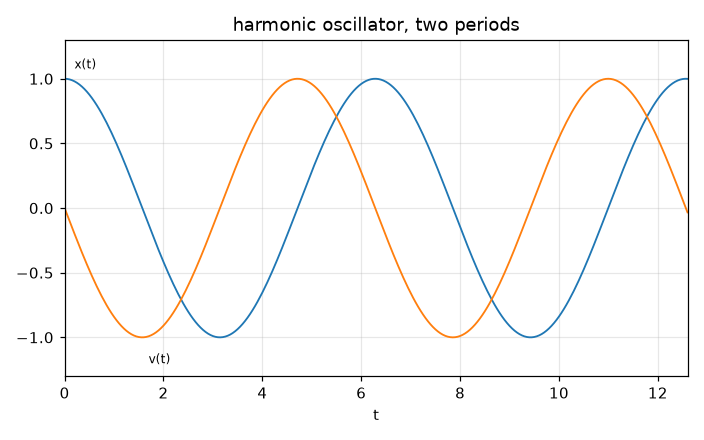

In [10]:
%%plot --title "harmonic oscillator, two periods" --xlabel "t" --grid
(define win (frame 0. 12.6 -1.3 1.3))
(plot-data win ts xs)
(plot-data win ts vs)
(graphics-draw-text win .2 1.08 "x(t)")
(graphics-draw-text win 1.7 -1.2 "v(t)")

Position and velocity, a quarter period out of phase. Position leads: the particle
is at rest at the turning points and moving fastest at the origin.

Now the same motion drawn in phase space, $(q, p)$ rather than against time. With
$m = 1$ we have $p = v$. Three initial amplitudes give three curves.

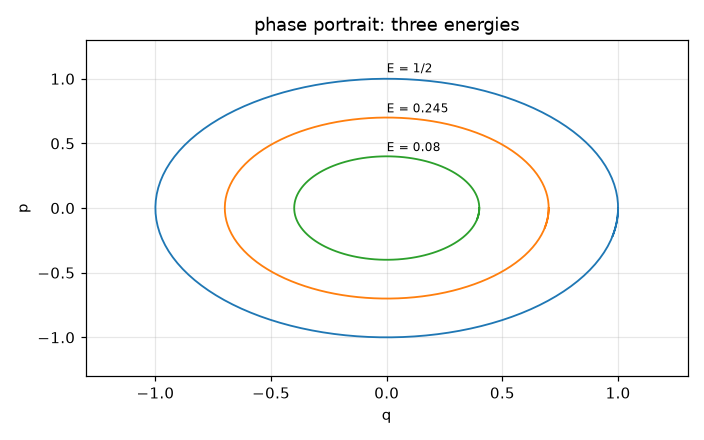

In [11]:
%%plot --title "phase portrait: three energies" --xlabel "q" --ylabel "p" --grid
(define win (frame -1.3 1.3 -1.3 1.3))
(for-each
  (lambda (x0)
    (let ((tr (states (up 0. x0 0.) .05 130)))
      (plot-data win
                 (map (lambda (s) (ref s 1)) tr)
                 (map (lambda (s) (ref s 2)) tr))))
  (list 1. .7 .4))
(graphics-draw-text win .0 1.05 "E = 1/2")
(graphics-draw-text win .0 .74 "E = 0.245")
(graphics-draw-text win .0 .44 "E = 0.08")

Circles -- ellipses in general -- one per energy, traversed clockwise. The energy
$E = \tfrac12(p^2 + q^2)$ is half the squared radius, and the area enclosed is
$2\pi E/\omega$.

That area is the bridge to quantum mechanics. The old Bohr-Sommerfeld rule guessed
that only orbits enclosing an area of $nh$ are allowed; the real answer, which
notebook 3 derives, is $(n + \tfrac12)h$. The classical picture has a continuum
of circles and the quantum one keeps a discrete set of them.

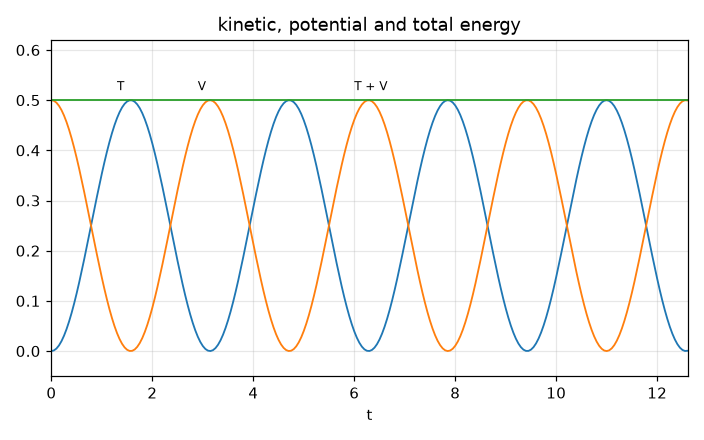

In [12]:
%%plot --title "kinetic, potential and total energy" --xlabel "t" --grid
(define win (frame 0. 12.6 -.05 .62))
(plot-data win ts (map (lambda (s) (* 1/2 (square (ref s 2)))) traj))
(plot-data win ts (map (lambda (s) (* 1/2 (square (ref s 1)))) traj))
(plot-data win ts (map (lambda (s) (E s)) traj))
(graphics-draw-text win 1.3 .52 "T")
(graphics-draw-text win 2.9 .52 "V")
(graphics-draw-text win 6.0 .52 "T + V")

$T$ and $V$ each oscillate at twice the frequency of $x$ and trade off perfectly;
their sum is the flat line at $E = 1/2$. They cross at $E/2$ -- averaged over a
period, kinetic and potential energy are equal. That equality survives
quantization: in the quantum ground state
$\langle T\rangle = \langle V\rangle = \hbar\omega/4$, which notebook 3 checks
by integration.

## What to carry forward

- A Lagrangian or Hamiltonian written as a procedure is enough; the equations of
  motion are *derived*, not typed in.
- $H = p^2/2m + \tfrac12 k q^2$ is the object we quantize.
- Classically, energy is continuous: every circle in phase space is a legal orbit.
  The single most important thing quantum mechanics changes is that this becomes
  false.

Next: [the particle in a box](02-particle-in-a-box.ipynb), the simplest system
in which energy is forced to be discrete.